# Ablation study (GE Huggett)

Systematic **batch-size** experiments for the U-Net / distribution policy in the same GE environment as `main.ipynb`. Resulting figures are written to **`figures_tables/`**; run with the **repository root** as the working directory and with `results/*.pkl` from training if you re-execute.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax
# Use double precision, important for stability, yet slower
# We may not use this when training the neural networks if it is costly
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import haiku as hk 
import optax
import matplotlib.pyplot as plt
import time
import numpy as np
import pickle
colors = [
    "royalblue", "green", "orange", "red", "navy", "brown", "teal", "pink", "gray"
]

def set_static_styles():
    plt.rcParams.update({
        'axes.titlesize': 20,
        'axes.labelsize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 14,
        'lines.linewidth': 3,
        'lines.markersize': 6,
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Bitstream Vera Serif', 'Computer Modern Roman', 'New Century Schoolbook', 'Century Schoolbook L', 'Utopia', 'ITC Bookman', 'Bookman', 'Nimbus Roman No9 L', 'Palatino', 'Charter', 'serif']
    })

def create_subplots(nrow=1,ncol=1,sharex=False,sharey=False):
    set_static_styles()
    width, height = 6*ncol, 4.5*nrow
    fig, axs = plt.subplots(nrow, ncol, figsize=(width, height),sharex=sharex,sharey=sharey)
    if nrow*ncol == 1:
        axs = [[axs]]
    elif nrow == 1:
        axs = [axs]
    elif ncol == 1:
        axs = [[ax] for ax in axs]
    return fig, axs

## Step 1 — Economy (GE Huggett)

Define asset / productivity / TFP grids and transitions; bond supply \(B\) pins equilibrium \(r\) as in the companion scripts.


In [2]:
seed = 0
key = jax.random.PRNGKey(seed)
# wealth grid
na = 200 # number of asset grid points
a_min = 0.0 # minimum asset level (borrowing limit)
a_max = 150.0 # maximum asset level
a_grid = jnp.geomspace(0.25,a_max-a_min,na) + a_min - 0.25 # asset grid
# income process
ne = 3 # number of income states
e_grid = jnp.asarray([0.5488, 1.000, 1.8221]) # income states
e_trans = jnp.asarray(
    [[0.6460, 0.3539, 0.0001],
    [0.0304, 0.9392, 0.0304],
    [0.0001, 0.3539, 0.6460]]) # income transition matrix
# compute the stationary distribution of income
A = jnp.transpose(e_trans) - jnp.eye(ne)
A = jnp.vstack([A, jnp.ones(ne)])
b = jnp.zeros(ne + 1)
b = b.at[-1].set(1.0)
e_dist_stationary = jnp.linalg.lstsq(A, b, rcond=None)[0]
e_mean = jnp.sum(e_dist_stationary * e_grid)
e_grid = e_grid / e_mean # normalize mean income to 1
a_dist = jnp.repeat(a_grid, ne).reshape(na,ne) # initial wealth distribution
e_dist = jnp.tile(e_grid, na).reshape(na,ne) # initial income distribution
# TFP shock process
nz = 5 # number of TFP states
z_grid = jnp.asarray([0.9139, 0.9560, 1.0000, 1.0460, 1.0942]) # TFP states
z_trans = jnp.asarray(
    [[0.8478, 0.1522, 0.0000, 0.0000, 0.0000],
    [0.0195, 0.8962, 0.0843, 0.0000, 0.0000],
    [0.0000, 0.0427, 0.9147, 0.0427, 0.0000],
    [0.0000, 0.0000, 0.0843, 0.8962, 0.0195],
    [0.0000, 0.0000, 0.0000, 0.1522, 0.8478]]) # TFP transition matrix
# model parameters
beta = 0.975 # discount factor
sigma = 1 # relative risk aversion
trunc_eps = 1e-2 # truncation error for infinite horizon problem
min_c = 1e-3 # minimum consumption to avoid numerical issues
B = 5 # total bond supply
T = jnp.floor(jnp.log(trunc_eps) / jnp.log(beta)).astype(int) # time horizon for finite horizon problem
@jax.jit
def utility(c,sigma):
    return jax.lax.cond(
        sigma == 1.0,
        lambda : jnp.log(c),
        lambda : c**(1.0 - sigma) / (1.0 - sigma)
    )

**Bond clearing for \(r\) without aggregate TFP risk** (here \(z\) is fixed at one in this exercise).


In [3]:
@jax.jit
def iterpolate_nonuniform(x, grids):
    # make x within the grid range
    x = jnp.clip(x, grids[0], grids[-1])
    idx = jnp.searchsorted(grids, x) - 1
    idx = jnp.clip(idx, 0, len(grids)-2)
    x0, x1 = grids[idx], grids[idx+1]
    y0, y1 = idx.astype(int), (idx+1).astype(int)
    w0 = (x1 - x) / (x1 - x0 + 1e-12)
    w1 = 1.0 - w0
    return y0, y1, w0, w1

@jax.jit
def update_V(aidx,V,r):
    def loop_e(eidx):
        a, e = a_grid[aidx], e_grid[eidx]
        wealth = (1+r)*a + e
        def find_all_v(c):
            next_wealth = wealth - c
            y0, y1, w0, w1 = iterpolate_nonuniform(next_wealth, a_grid)
            expected_future_V = jnp.sum((V[y0]*w0 + V[y1]*w1)*e_trans[eidx])
            return utility(c,sigma) + beta * expected_future_V
        cgrid = jnp.linspace(1e-3, wealth - a_min, 8192)
        expected_Vs = jax.vmap(find_all_v)(cgrid)
        expected_V = jnp.max(expected_Vs)
        opt_c = cgrid[jnp.argmax(expected_Vs)]
        return expected_V, opt_c
    return jax.vmap(loop_e)(jnp.arange(ne))

def vfi(r):
    V = jnp.zeros((na,ne))
    while True:
        V_new,opt_c = jax.vmap(update_V,in_axes=(0,None,None))(jnp.arange(na),V,r)
        if jnp.max(jnp.abs(V_new - V)) < 1e-7:
            break
        V = V_new
    return V, opt_c

@jax.jit
def state_transit(opt_c,g,r):
    def loop_a(aidx):
        def loop_e(eidx):
            a, e = a_grid[aidx], e_grid[eidx]
            wealth = (1+r)*a + e
            c = opt_c[aidx,eidx]
            next_wealth = wealth - c
            y0, y1, w0, w1 = iterpolate_nonuniform(next_wealth, a_grid)
            g_new = jnp.zeros((na,ne))
            g_new = g_new.at[y0].set(g[aidx,eidx]*w0*e_trans[eidx])
            g_new = g_new.at[y1].set(g[aidx,eidx]*w1*e_trans[eidx])
            return g_new
        return jax.vmap(loop_e)(jnp.arange(ne))
    return jax.vmap(loop_a)(jnp.arange(na)).sum(axis=(0,1))

@jax.jit
def compute_stationary_dis(opt_c,r):
    g = jnp.full((na,ne),1.0/(na*ne))
    def step(g,_):
        return state_transit(opt_c,g,r), g
    return jax.lax.scan(step,g,length=2000)


# outer loop: binary search for interest rate r
left, right = 0.0, 0.1
while left < right:
    mid = (left + right) / 2.0
    V,opt_c = vfi(mid)
    g,g_all = compute_stationary_dis(opt_c,mid)
    asset_supply_err = jnp.sum(g*a_dist) - B
    if asset_supply_err > 0.0:
        right = mid
    else:
        left = mid
    print(f"r: {mid:.6f}, asset supply err: {asset_supply_err:.3E}")
    if jnp.abs(asset_supply_err) < 1e-5:
        break
steady_r = mid
steady_dist = g
print(f"Equilibrium interest rate: {steady_r:.6f}")
print(f"Aggregate saving at equilibrium: {asset_supply_err + B:.3E}")

r: 0.050000, asset supply err: 1.447E+02
r: 0.025000, asset supply err: 4.316E+00
r: 0.012500, asset supply err: -4.514E+00
r: 0.018750, asset supply err: -4.037E+00
r: 0.021875, asset supply err: -3.386E+00
r: 0.023438, asset supply err: -2.533E+00
r: 0.024219, asset supply err: -1.544E+00
r: 0.024609, asset supply err: -4.640E-01
r: 0.024805, asset supply err: 9.258E-01
r: 0.024707, asset supply err: 7.674E-02
r: 0.024658, asset supply err: -2.132E-01
r: 0.024683, asset supply err: -7.848E-02
r: 0.024695, asset supply err: -1.929E-03
r: 0.024701, asset supply err: 3.998E-02
r: 0.024698, asset supply err: 1.556E-02
r: 0.024696, asset supply err: 4.866E-03
r: 0.024696, asset supply err: 2.491E-03
r: 0.024695, asset supply err: -6.106E-04
r: 0.024695, asset supply err: 8.777E-05
r: 0.024695, asset supply err: -9.780E-05
r: 0.024695, asset supply err: -5.022E-06
Equilibrium interest rate: 0.024695
Aggregate saving at equilibrium: 5.000E+00


## Step 2 — Policy network

Haiku U-Net maps **distribution \(\mathbf g\)** (and \(r\)) into consumption-share weights.


$$
\texttt{U-Net}(\mathbf{g},r) = \mathbf{c}_{\texttt{share}}(z)
$$

Shares \(\mathbf{c}_{\texttt{share}}(z)\) parameterize consumption on the asset grid conditional on \(z\).


In [5]:
activation = jax.nn.leaky_relu
pool = hk.AvgPool
# consumption bounds: c in [min_c, max_csmp]
# max_csmp: maximum consumption given borrowing limit a_min and not greater than 2*opt_c
diffs = jnp.diff(opt_c,axis=0)
max_diff = jnp.zeros((na,ne))
max_diff = max_diff.at[0,:].set(diffs[0,:])
max_diff = max_diff.at[1:,:].set(diffs)
max_diff *= 2.0
csmp0 = opt_c[0,:] - jnp.asarray([0.05,0.02,0.1])

class DoubleConv(hk.Module):
    def __init__(self, out_channels, name=None):
        super().__init__(name=name)
        self.out_channels = out_channels

    def __call__(self, x):
        x = hk.Conv1D(output_channels=self.out_channels, kernel_shape=3, stride=1, padding='SAME')(x)
        x = activation(x)
        x = hk.Conv1D(output_channels=self.out_channels, kernel_shape=3, stride=1, padding='SAME')(x)
        x = activation(x)
        return x
    
def forward_fn(g):
    # g: (B, na, ne), r: (B,) -> c: (B, na, ne)
    # normalize the input
    g = g / jnp.sum(g, axis=(1,2), keepdims=True)
    g = g * na * ne
    # Layer 1: from (B, na, ne) to (B, na, 8)
    x1 = DoubleConv(4)(g)
    # Layer 2: from (B, na, 8) to (B, na//2, 16)
    x2 = pool(window_shape=2, strides=2, padding='SAME')(x1)
    x2 = DoubleConv(4)(x2)
    # Layer 3: from (B, na//2, 16) to (B, na//4, 32)
    x3 = pool(window_shape=2, strides=2, padding='SAME')(x2)
    x3 = DoubleConv(4)(x3)
    # layer 4: from (B, na//4, 32) to (B, na//8, 64)
    #x4 = pool(window_shape=2, strides=2, padding='SAME')(x3)
    #x4 = DoubleConv(32)(x4)

    y = x3
    # Layer 5: from (B, na//8, 64) to (B, na//4, 32)
    #y = hk.Conv1DTranspose(output_channels=32, kernel_shape=3, stride=2, padding='SAME')(x4)
    #y = y[:, :x3.shape[1], :]  # crop if needed
    #y = jnp.concatenate([y, x3], axis=-1)
    #y = DoubleConv(32)(y)
    # Layer 6: from (B, na//4, 32) to (B, na//2, 16)
    y = hk.Conv1DTranspose(output_channels=4, kernel_shape=3, stride=2, padding='SAME')(y)
    y = y[:, :x2.shape[1], :]  # crop if needed
    y = jnp.concatenate([y, x2], axis=-1)
    y = DoubleConv(4)(y)
    # Layer 7: from (B, na//2, 16) to (B, na, 8)
    y = hk.Conv1DTranspose(output_channels=4, kernel_shape=3, stride=2, padding='SAME')(y)
    y = y[:, :x1.shape[1], :]  # crop if needed
    y = jnp.concatenate([y, x1], axis=-1)
    y = DoubleConv(4)(y)
    # Final layer: from (B, na, 8) to (B, na, ne*nz)
    y = hk.Conv1D(output_channels=ne*nz, kernel_shape=1, stride=1, padding='SAME')(y)
    #y = hk.Linear(ne*nz)(y)
    y = jax.nn.sigmoid(y.reshape(y.shape[0], na, ne, nz))
    # output consumption: c in [min_c, max_csmp]
    c = jnp.zeros((y.shape[0], na+1, ne, nz))
    c = c.at[:,0,:,:].set(
        csmp0[None,:,None] * jnp.ones((y.shape[0],ne,nz))
    )
    c = c.at[:,1:,:,:].set(
        y * max_diff[None,...,None]
    )
    c = jnp.cumsum(c, axis=1)
    c = c[:,1:,:,:]
    return c

## Step 3 — Train the U-Net with DSPG

Distribution-based structural policy gradient (**DSPG**) updates the U-Net by differentiating through the simulated general-equilibrium objective.


In [11]:
batch_size = 512
epoch = 1000

In [ ]:
@jax.jit
def update_g(wealth_next_batch,g_batch):
    def loop_B(wealth_next,g):
        def loop_a(aidx):
            def loop_e(eidx):
                next_a = wealth_next[aidx,eidx]
                y0, y1, w0, w1 = iterpolate_nonuniform(next_a, a_grid)
                g_new = jnp.zeros((na,ne))
                enext_prob = e_trans[eidx]
                g_new = g_new.at[y0].set(g[aidx,eidx]*w0*enext_prob)
                g_new = g_new.at[y1].set(g[aidx,eidx]*w1*enext_prob)
                return g_new
            return jax.vmap(loop_e)(jnp.arange(ne))
        return jax.vmap(loop_a)(jnp.arange(na))
    return jax.vmap(loop_B)(wealth_next_batch,g_batch).sum(axis=(1,2))
data_dict = {}
for repeat_idx in range(10):
    print(f"Training repeat idx: {repeat_idx}")
    forward = hk.without_apply_rng(hk.transform(forward_fn))
    dummy_g = jnp.ones((2, na, ne))
    _key,key = jax.random.split(key)
    params = forward.init(_key, dummy_g)
    train_lr = optax.exponential_decay(2e-3,epoch,0.5)
    optimizer = optax.adam(train_lr)
    opt_state = optimizer.init(params)
    def cumulative_utility_loss(params,key,g):
        def step(pack,_):
            g_batch, zidx, discount, key = pack
            c_of_z = forward.apply(params, g_batch) # (B, na, ne, nz)
            def assign_c(idx,y):
                return y[...,idx]
            c = jax.vmap(assign_c)(zidx,c_of_z) # (B, na, ne)
            C = jnp.sum(c * g_batch, axis=(1,2)) # (B,)
            R = (B + C - z_grid[zidx]*jnp.sum(g_batch*e_dist[None,...],axis=(1,2))) / jnp.sum(g_batch*a_dist[None,...], axis=(1,2))  # (B,)
            r = R - 1
            # r = jnp.clip(r, 0.5 * steady_r, 1.5 * steady_r)
            r = jax.lax.stop_gradient(r)
            wealth = (1 + r[:,None,None]) * a_dist[None,...] + e_dist[None,...] * z_grid[zidx][:,None,None] # (B,na,ne)

            # update g
            c = jnp.minimum(c, wealth - a_min - min_c) # ensure feasibility
            wealth_next = wealth - c # (B,na,ne)
            g_batch = update_g(wealth_next,g_batch)
            util = jnp.sum(utility(c,sigma) * g_batch,axis=(1,2)) * discount # (B,)
            discount *= beta
            _key, key = jax.random.split(key)
            keys = jax.random.split(_key,batch_size)
            def update_z(idx,key):
                return jax.random.choice(key,nz,p=z_trans[idx])
            zidx = jax.vmap(update_z)(zidx,keys)
            return (g_batch, zidx, discount, key), util

        key,_key = jax.random.split(key)
        zidx = jax.random.choice(_key,nz,(batch_size,))
        discount = 1.0
        (final_g, _, _, _), utilities = jax.lax.scan(step, (g, zidx, discount, key), None, length=T)
        # utilities: (T,B)
        total_utility = jnp.sum(utilities,axis=0).mean() # ()
        return -total_utility, final_g
    @jax.jit
    def train_step_2(params, opt_state, key):
        # g = jnp.ones((batch_size, na, ne)) / (na*ne)
        g = jnp.ones((batch_size, na, ne)) * steady_dist[None,...]
        (loss,final_g), grads = jax.value_and_grad(cumulative_utility_loss,has_aux=True)(params,key,g)
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        agg_saving = jnp.sum(final_g * a_dist[None,...], axis=(1,2))
        return params, opt_state, loss, agg_saving
    
    tgts = []
    st = time.time()
    for ep in range(epoch):
        key,_key = jax.random.split(key)
        params, opt_state, loss, agg_saving = train_step_2(params, opt_state, _key)
        tgts.append(-loss.item())
        if ep % 10 == 0 or ep == epoch - 1:
            print(f"Train Epoch {ep+1}, Target: {-loss:.6f}, Aggregate Saving: {agg_saving.min():.3E}-{agg_saving.max():.3E}")
    et = time.time()
    print(f"Training time: {et - st:.2f} seconds")
    data_dict[repeat_idx] = jnp.asarray(tgts), params, et - st
# save the data
with open(f"results/DSPG_bs{batch_size}_ep{epoch}.pkl","wb") as f:
    pickle.dump(data_dict,f)

## Step 4 — Plots

Batch-size sensitivity: figures saved under `figures_tables/` (paths are relative to the repo root).


Final target mean/std over 10 runs (bs=32): 0.170434
Average runtime over 10 runs (bs=32): 335.84 seconds, std: 0.44 seconds
Final target mean/std over 10 runs (bs=128): 0.142974
Average runtime over 10 runs (bs=128): 954.31 seconds, std: 0.51 seconds
Final target mean/std over 10 runs (bs=512): 0.134920
Average runtime over 10 runs (bs=512): 2891.64 seconds, std: 0.88 seconds


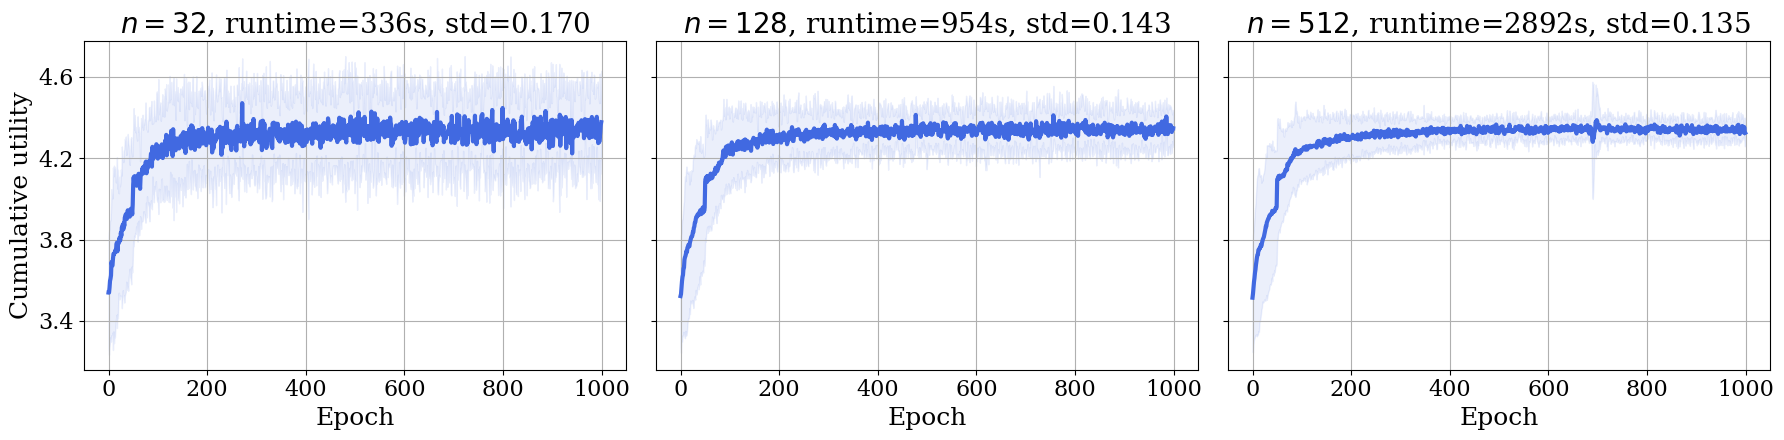

In [8]:
fig, axs = create_subplots(1,3,sharey=True)
sep = 1
for i,bs in enumerate([32,128,512]):
    with open(f"results/DSPG_bs{bs}_ep1000.pkl", "rb") as f:
        data = pickle.load(f)

    runtimes = []
    targets = []
    for repeat_idx in range(10):
        target,params,ergodic_dist,total_time = data[repeat_idx]
        runtimes.append(total_time)
        targets.append(target)
    avg_runtime = np.mean(runtimes)
    std_runtime = np.std(runtimes)
    avg_target = np.mean(np.array(targets),axis=0)
    std_target = np.std(np.array(targets),axis=0)
    std_end = np.array(targets)[-50:].std()
    print(f"Final target mean/std over 10 runs (bs={bs}): {std_end:.6f}")
    print(f"Average runtime over 10 runs (bs={bs}): {avg_runtime:.2f} seconds, std: {std_runtime:.2f} seconds")

    axs[0][i].plot(np.arange(len(avg_target))[::sep],avg_target[::sep], color=colors[0])#,marker='o')
    axs[0][i].fill_between(
        np.arange(len(avg_target))[::sep],
        (avg_target - 1.96*std_target)[::sep],
        (avg_target + 1.96*std_target)[::sep],
        color=colors[0],
        alpha=0.1,
    )
    axs[0][i].set_xlabel("Epoch")
    if i == 0:
        axs[0][i].set_ylabel("Cumulative utility")
        axs[0][i].set_yticks([3.4,3.8,4.2,4.6])
    axs[0][i].set_title(fr"$n={bs}$, runtime={avg_runtime:.0f}s, std={std_end:.3f}")
    axs[0][i].grid(True)
    #axs[0][i].set_ylim(3.25, 3.65)
ergodic_dist = ergodic_dist / jnp.sum(ergodic_dist) # ergodic distribution from the last run
fig.tight_layout()
fig.savefig(f"figures_tables/DSPG_ablation(bs).pdf")

## Step 5 — Comparison to SPG

Contrast DSPG-trained policies / distributions with the **SPG** baseline pickles loaded from `results/` (same plotting style as in the paper).


**Ergodic distribution** (cross-sectional density / mass over states)


In [9]:
with open("results/huggett_compare_DSPG.pkl","rb") as f:
    spg_data = pickle.load(f)
spg_data[0].keys()

dict_keys(['params', 'solve_times', 'converge_times', 'ergodic_dist', 'logs'])

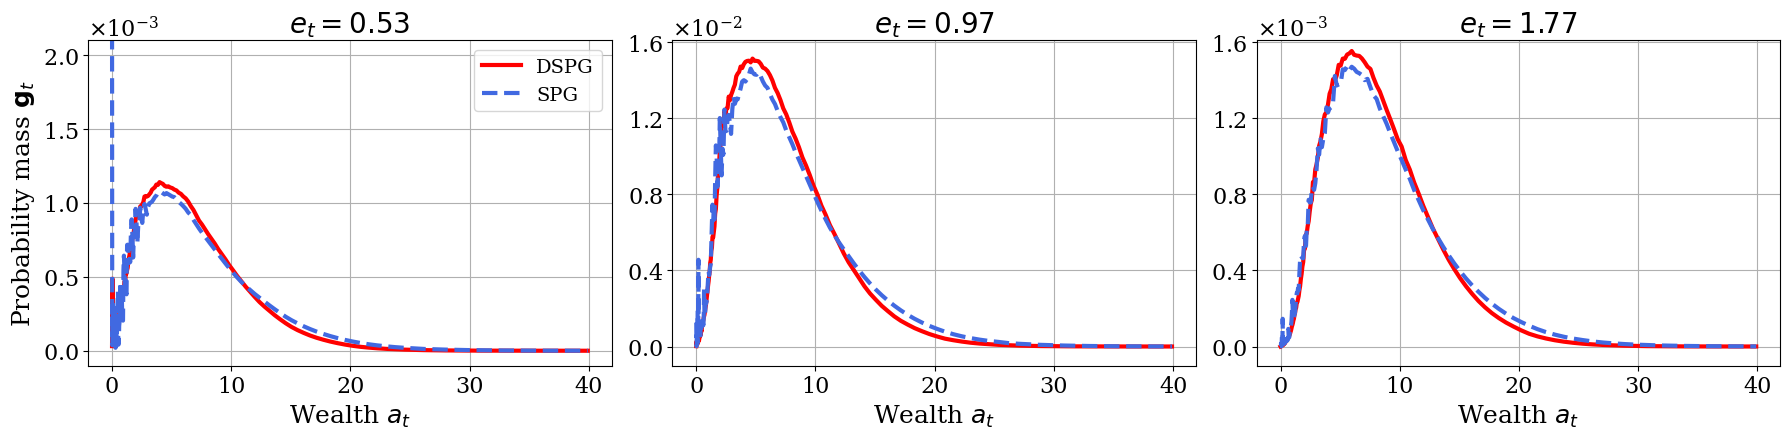

In [10]:
import matplotlib.ticker as ticker
fig, axs = create_subplots(1,3)
idxx = jnp.where(a_grid <= 40)[0]
ylabels = [
    [0,0.0005,0.0010,0.0015,0.0020],
    [0,0.004,0.008,0.012,0.016],
    [0,0.0004,0.0008,0.0012,0.0016]
]
ylims = [
    (-0.0001,0.0021),
    (-0.001,0.0161),
    (-0.0001,0.00161)
]
for eidx in range(ne):
    ax = axs[0][eidx]
    ax.plot(a_grid[idxx],ergodic_dist[idxx,eidx],label="DSPG",color="red")
    ax.plot(a_grid[idxx],spg_data[0]["ergodic_dist"].mean(0).reshape(na,ne)[idxx,eidx],label=f"SPG",color=colors[0],linestyle="dashed")
    ax.set_xlabel("Wealth $a_t$")
    if eidx == 0:
        ax.set_ylabel("Probability mass $\mathbf{g}_t$")
    ax.set_title(f"$e_t={e_grid[eidx]:.2f}$")
    if eidx==0: ax.legend()
    ax.grid(True)
    ax.set_yticks(ylabels[eidx])
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(formatter)
    ax.set_ylim(ylims[eidx])
    ax.set_xticks([0,10,20,30,40])
fig.tight_layout()
fig.savefig("figures_tables/DSPG_vs_SPG_ergodic_dist.pdf")


**Interest rate distribution** (implied by simulation and policy)


In [11]:
with open("results/DSPG_bs512_ep1000.pkl","rb") as f:
    params = pickle.load(f)[0][1]
@jax.jit
def update_g(wealth_next_batch,g_batch):
    def loop_B(wealth_next,g):
        def loop_a(aidx):
            def loop_e(eidx):
                next_a = wealth_next[aidx,eidx]
                y0, y1, w0, w1 = iterpolate_nonuniform(next_a, a_grid)
                g_new = jnp.zeros((na,ne))
                enext_prob = e_trans[eidx]
                g_new = g_new.at[y0].set(g[aidx,eidx]*w0*enext_prob)
                g_new = g_new.at[y1].set(g[aidx,eidx]*w1*enext_prob)
                return g_new
            return jax.vmap(loop_e)(jnp.arange(ne))
        return jax.vmap(loop_a)(jnp.arange(na))
    return jax.vmap(loop_B)(wealth_next_batch,g_batch).sum(axis=(1,2))
forward = hk.without_apply_rng(hk.transform(forward_fn))
def simulation(params,key,traj_n=1024):
    def step(pack,_):
        g_batch, zidx, discount, key = pack
        c_of_z = forward.apply(params, g_batch) # (B, na, ne, nz)
        z = z_grid[zidx]
        def assign_c(idx,y):
            return y[...,idx]
        c = jax.vmap(assign_c)(zidx,c_of_z) # (B, na, ne)
        C = jnp.sum(c * g_batch, axis=(1,2)) # (B,)
        R = (B + C - z_grid[zidx]) / jnp.sum(g_batch*a_dist[None,...], axis=(1,2))  # (B,)
        r = R - 1
        # r = jnp.clip(r, 0.5 * steady_r, 1.5 * steady_r)
        r = jax.lax.stop_gradient(r)
        wealth = (1 + r[:,None,None]) * a_dist[None,...] + e_dist[None,...] * z_grid[zidx][:,None,None] # (B,na,ne)
        c = jnp.minimum(c, wealth - a_min - min_c) # ensure feasibility
        wealth_next = wealth - c # (B,na,ne)
        g_batch = update_g(wealth_next,g_batch)
        discount *= beta
        _key, key = jax.random.split(key)
        keys = jax.random.split(_key,traj_n)
        def update_z(idx,key):
            return jax.random.choice(key,nz,p=z_trans[idx])
        zidx = jax.vmap(update_z)(zidx,keys)
        return (g_batch, zidx, discount, key), (r, jnp.sum(g_batch*a_dist[None,...],axis=(1,2)),c,zidx)

    key,_key = jax.random.split(key)
    zidx = jax.random.choice(_key,nz,(traj_n,))
    g_batch = jnp.ones((traj_n, na, ne)) * ergodic_dist[None,...]
    discount = 1.0
    (final_g, _, _, _), data = jax.lax.scan(step, (g_batch, zidx, discount, key), None, length=T+500)
    # remove first 500 burn-in steps
    data = jax.tree_util.tree_map(lambda x: x[500:,...], data)
    return data,final_g
key,_key = jax.random.split(key)
(r,b,c,z),final_g = simulation(params,_key)
final_g.shape,r.shape,b.shape,c.shape,z.shape

((1024, 200, 3), (181, 1024), (181, 1024), (181, 1024, 200, 3), (181, 1024))

In [12]:
flat_z = z.flatten()
flat_r = r.flatten()
print(r"TFP & AVG & STD & MIN & MAX \\")
print("\hline")
for zidx in range(nz):
    idxx = jnp.where(flat_z==zidx)
    avg_r = flat_r[idxx].mean()
    min_r = flat_r[idxx].min()
    max_r = flat_r[idxx].max()
    std_r = flat_r[idxx].std()
    print(rf"{z_grid[zidx]:.2f} & {avg_r:.4f} & {std_r:.4f} & {min_r:.4f} & {max_r:.4f} \\")
print("\hline")

TFP & AVG & STD & MIN & MAX \\
\hline
0.91 & 0.0283 & 0.0007 & 0.0259 & 0.0300 \\
0.96 & 0.0267 & 0.0006 & 0.0236 & 0.0300 \\
1.00 & 0.0250 & 0.0008 & 0.0194 & 0.0272 \\
1.05 & 0.0222 & 0.0011 & 0.0152 & 0.0254 \\
1.09 & 0.0188 & 0.0016 & 0.0135 & 0.0234 \\
\hline


**Compare under fixed shock paths** (counterfactuals with aligned TFP trajectories)


In [13]:
with open("results/DSPG_bs512_ep1000.pkl","rb") as f:
    params = pickle.load(f)[0][1]
with open("results/huggett_compare_DSPG_simdata.pkl","rb") as f:
    huggett_data = pickle.load(f)
print(huggett_data.keys())
spg_zidx = huggett_data["z_idx"]
spg_r = huggett_data["r"]
spg_c = huggett_data["agg_c"]
@jax.jit
def update_g(wealth_next_batch,g_batch):
    def loop_B(wealth_next,g):
        def loop_a(aidx):
            def loop_e(eidx):
                next_a = wealth_next[aidx,eidx]
                y0, y1, w0, w1 = iterpolate_nonuniform(next_a, a_grid)
                g_new = jnp.zeros((na,ne))
                enext_prob = e_trans[eidx]
                g_new = g_new.at[y0].set(g[aidx,eidx]*w0*enext_prob)
                g_new = g_new.at[y1].set(g[aidx,eidx]*w1*enext_prob)
                return g_new
            return jax.vmap(loop_e)(jnp.arange(ne))
        return jax.vmap(loop_a)(jnp.arange(na))
    return jax.vmap(loop_B)(wealth_next_batch,g_batch).sum(axis=(1,2))
forward = hk.without_apply_rng(hk.transform(forward_fn))
def simulation(params,key):
    def step(pack,zidx):
        g_batch, discount, key = pack
        c_of_z = forward.apply(params, g_batch) # (B, na, ne, nz)
        def assign_c(idx,y):
            return y[...,idx]
        c = jax.vmap(assign_c)(zidx,c_of_z) # (B, na, ne)
        C = jnp.sum(c * g_batch, axis=(1,2)) # (B,)
        R = (B + C - z_grid[zidx]) / jnp.sum(g_batch*a_dist[None,...], axis=(1,2))  # (B,)
        r = R - 1
        # r = jnp.clip(r, 0.5 * steady_r, 1.5 * steady_r)
        r = jax.lax.stop_gradient(r)
        wealth = (1 + r[:,None,None]) * a_dist[None,...] + e_dist[None,...] * z_grid[zidx][:,None,None] # (B,na,ne)
        total_wealth = jnp.sum(g_batch*wealth,axis=(1,2))
        c = jnp.minimum(c, wealth - a_min - min_c) # ensure feasibility
        wealth_next = wealth - c # (B,na,ne)
        g_batch_new = update_g(wealth_next,g_batch)
        discount *= beta
        return (g_batch_new, discount, key), (r, jnp.sum(g_batch*a_dist[None,...],axis=(1,2)),C,zidx,total_wealth)
    traj_n = spg_zidx.shape[0]
    g_batch = jnp.ones((traj_n, na, ne)) * ergodic_dist[None,...]
    discount = 1.0
    (final_g, _, _), data = jax.lax.scan(step, (g_batch, discount, key), spg_zidx.T)
    return data,final_g
key,_key = jax.random.split(key)
(r,b,c,z,w),final_g = simulation(params,_key)
final_g.shape,r.shape,b.shape,c.shape,z.shape

dict_keys(['agg_c', 'z_idx', 'agg_saving', 'r', 'csmp_dist'])


((3, 200, 3), (1000, 3), (1000, 3), (1000, 3), (1000, 3))

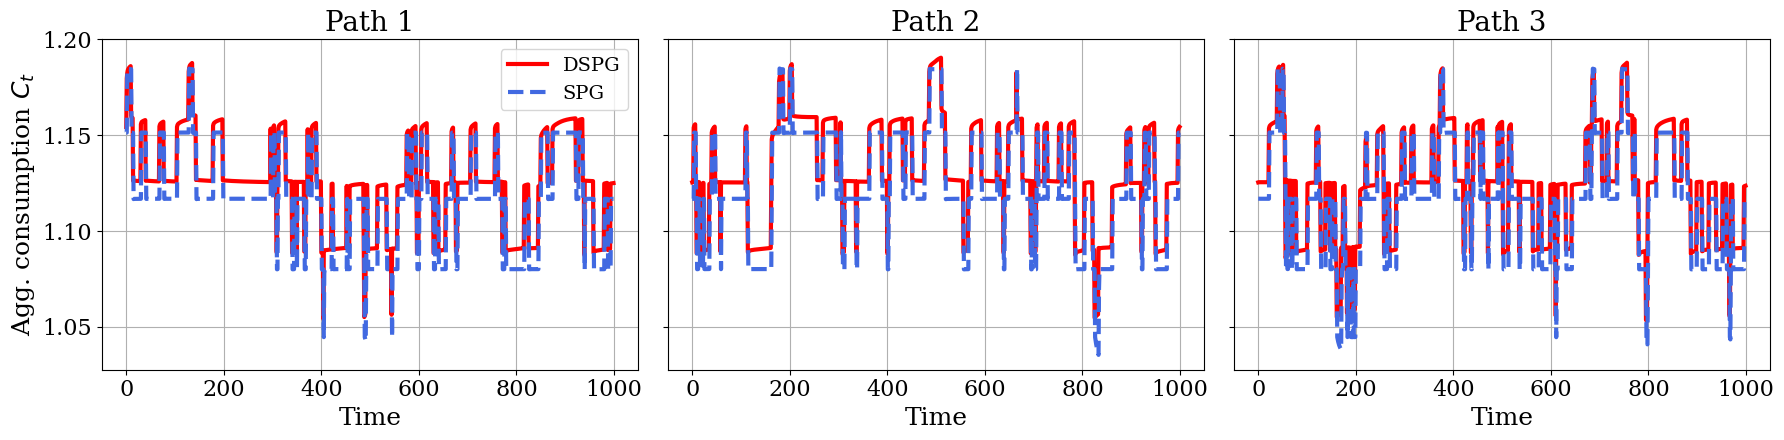

In [24]:
fig, axs = create_subplots(1,3,sharey=True)
len = 1000
for traj_idx in range(3):
    ax = axs[0][traj_idx]
    ax.plot(c[:len,traj_idx],label="DSPG",color="red")
    ax.plot(spg_c[traj_idx,:len],label="SPG",color=colors[0],linestyle="dashed")
    ax.set_xlabel("Time")
    if traj_idx == 0:
        ax.set_ylabel("Agg. consumption $C_t$")
    if traj_idx==0: ax.legend()
    ax.grid(True)
    ax.set_title(f"Path {traj_idx+1}")
    #ax.set_ylim(1.05,1.2)
    ax.set_yticks([1.05,1.10,1.15,1.20])
fig.tight_layout()
fig.savefig("figures_tables/DSPG_vs_SPG_consumption.pdf")